# Bangalore Real Estate Analysis
### SQL-based analysis of 13,000+ residential property listings

This notebook presents the results of a MySQL analysis on the Bengaluru House Price Dataset (Kaggle).
All queries were written and executed in MySQL. Results are visualized here using Python.

**Tools used:** MySQL (querying), Python/pandas/matplotlib (visualization)  
**Dataset:** Bengaluru House Price Data — 13,170 cleaned listings across Bangalore localities  
**Key questions:**
- Which localities command the highest price per sqft?
- How does BHK type affect pricing?
- Where is supply concentrated?
- Which properties are outliers relative to their locality average?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11


## Query 1 — Average Price per Sqft by Locality (Top 20)
Localities with fewer than 10 listings excluded to avoid single-listing distortions.

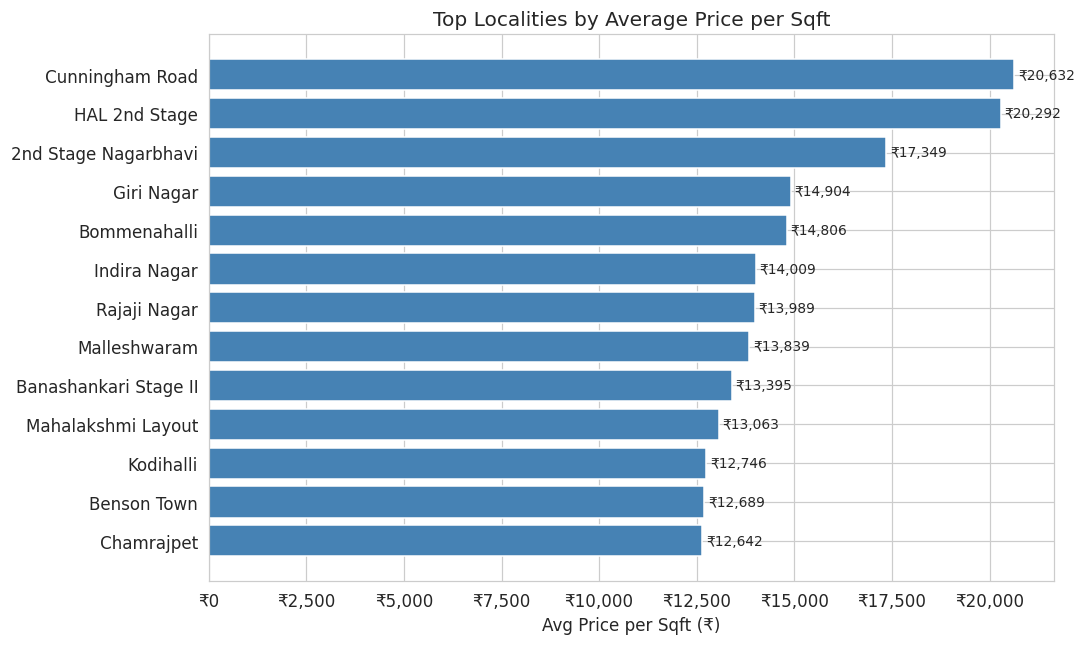

,location,avg_price_per_sqft,total_listings
0,Cunningham Road,20632.48,13
1,HAL 2nd Stage,20291.83,11
2,2nd Stage Nagarbhavi,17349.23,24
3,Giri Nagar,14904.45,14
4,Bommenahalli,14806.42,11
5,Indira Nagar,14009.30,44
6,Rajaji Nagar,13989.07,106
7,Malleshwaram,13838.68,57
8,Banashankari Stage II,13394.56,16
9,Mahalakshmi Layout,13063.47,13


In [2]:
q1 = pd.DataFrame({
    'location': ['Cunningham Road','HAL 2nd Stage','2nd Stage Nagarbhavi','Giri Nagar',
                 'Bommenahalli','Indira Nagar','Rajaji Nagar','Malleshwaram',
                 'Banashankari Stage II','Mahalakshmi Layout','Kodihalli',
                 'Benson Town','Chamrajpet'],
    'avg_price_per_sqft': [20632.48,20291.83,17349.23,14904.45,14806.42,
                            14009.3,13989.07,13838.68,13394.56,13063.47,
                            12745.7,12688.82,12641.82],
    'total_listings': [13,11,24,14,11,44,106,57,16,13,15,15,14]
})

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(q1['location'], q1['avg_price_per_sqft'], color='steelblue')
ax.set_xlabel('Avg Price per Sqft (₹)')
ax.set_title('Top Localities by Average Price per Sqft')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for bar, val in zip(bars, q1['avg_price_per_sqft']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/q1_price_per_sqft.png', dpi=150, bbox_inches='tight')
plt.show()
q1


**Key insight:** Cunningham Road (₹20,632/sqft) and HAL 2nd Stage (₹20,291/sqft) are the priciest localities — both are established, centrally located areas. Rajaji Nagar stands out: 106 listings at ₹13,989/sqft, suggesting it's both premium *and* high-supply, which is unusual.

## Query 2 — BHK Distribution and Pricing

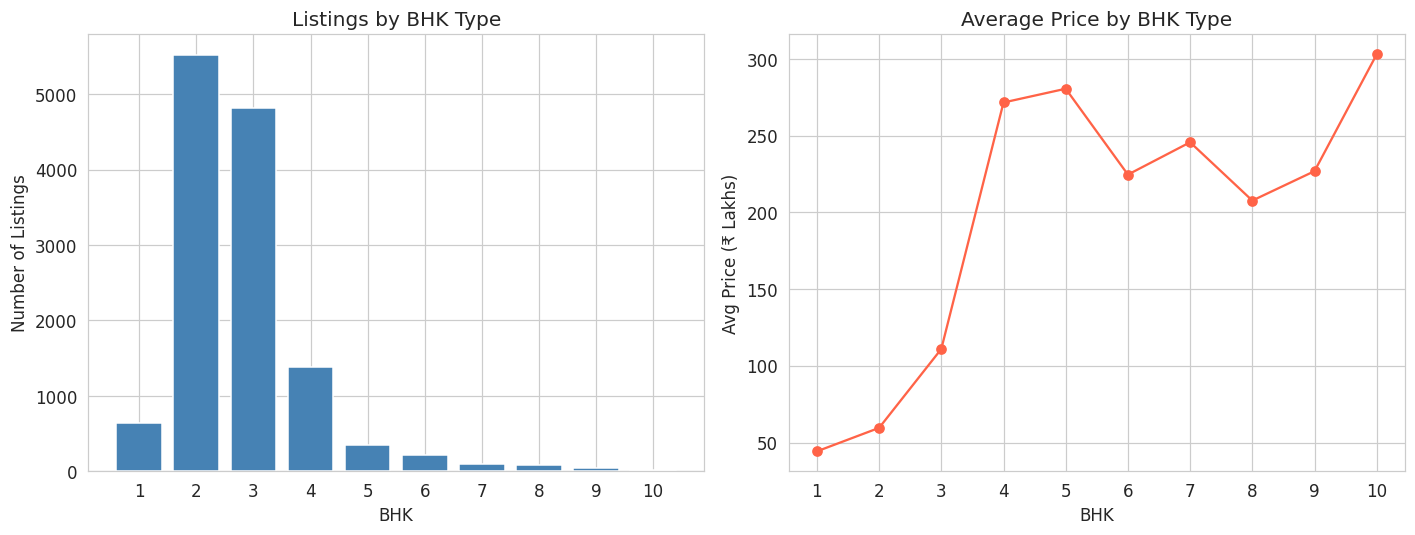

,bhk,total_listings,avg_price_lakhs,avg_price_per_sqft
0,1,638,44.24,6172.90
1,2,5517,59.54,5180.26
2,3,4817,110.96,6432.93
3,4,1388,271.60,10468.48
4,5,348,280.57,12036.97
5,6,220,224.60,12547.76
6,7,99,245.68,11691.44
7,8,85,207.67,13086.79
8,9,48,226.85,12589.83
9,10,10,303.00,15933.26


In [3]:
q2 = pd.DataFrame({
    'bhk': [1,2,3,4,5,6,7,8,9,10],
    'total_listings': [638,5517,4817,1388,348,220,99,85,48,10],
    'avg_price_lakhs': [44.24,59.54,110.96,271.6,280.57,224.6,245.68,207.67,226.85,303],
    'avg_price_per_sqft': [6172.9,5180.26,6432.93,10468.48,12036.97,12547.76,11691.44,13086.79,12589.83,15933.26]
})

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].bar(q2['bhk'], q2['total_listings'], color='steelblue')
axes[0].set_xlabel('BHK')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Listings by BHK Type')
axes[0].set_xticks(q2['bhk'])

axes[1].plot(q2['bhk'], q2['avg_price_lakhs'], marker='o', color='tomato', label='Avg Price (₹ Lakhs)')
axes[1].set_xlabel('BHK')
axes[1].set_ylabel('Avg Price (₹ Lakhs)')
axes[1].set_title('Average Price by BHK Type')
axes[1].set_xticks(q2['bhk'])

plt.tight_layout()
plt.savefig('outputs/q2_bhk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
q2


**Key insight:** 2 BHK (5,517) and 3 BHK (4,817) dominate supply — together they account for nearly 78% of all listings. Price jumps sharply from 3 BHK (₹111L) to 4 BHK (₹272L), suggesting 4+ BHK properties are in a different market segment entirely.

## Query 3 — Localities with Most Listings (Supply Concentration)

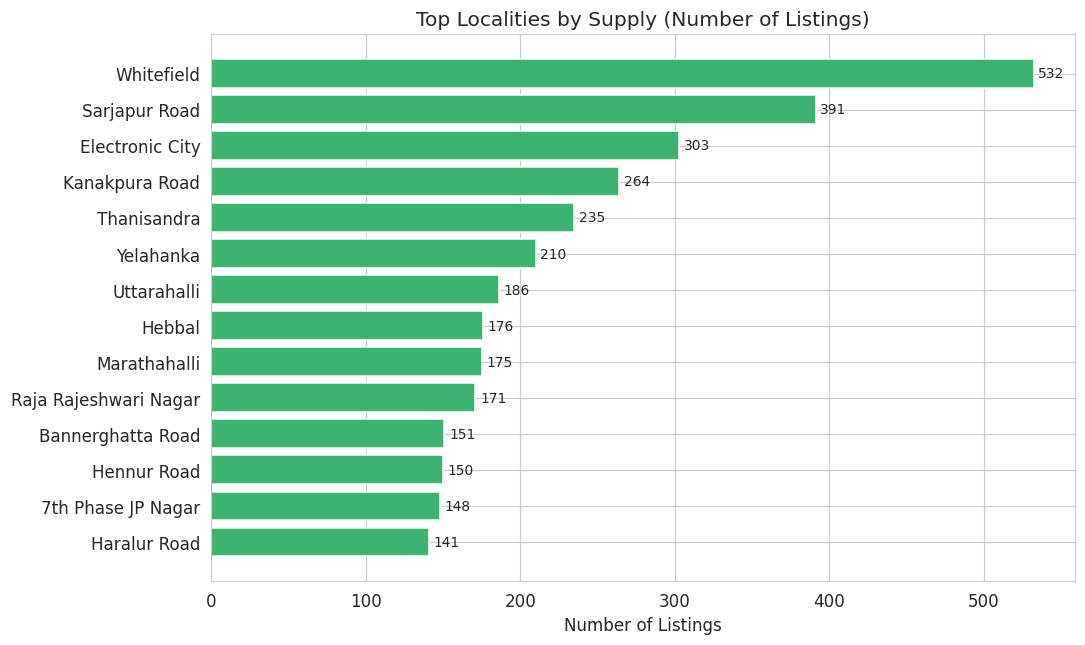

,location,total_listings
0,Whitefield,532
1,Sarjapur Road,391
2,Electronic City,303
3,Kanakpura Road,264
4,Thanisandra,235
5,Yelahanka,210
6,Uttarahalli,186
7,Hebbal,176
8,Marathahalli,175
9,Raja Rajeshwari Nagar,171


In [4]:
q3 = pd.DataFrame({
    'location': ['Whitefield','Sarjapur Road','Electronic City','Kanakpura Road',
                 'Thanisandra','Yelahanka','Uttarahalli','Hebbal',
                 'Marathahalli','Raja Rajeshwari Nagar','Bannerghatta Road',
                 'Hennur Road','7th Phase JP Nagar','Haralur Road'],
    'total_listings': [532,391,303,264,235,210,186,176,175,171,151,150,148,141]
})

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(q3['location'], q3['total_listings'], color='mediumseagreen')
ax.set_xlabel('Number of Listings')
ax.set_title('Top Localities by Supply (Number of Listings)')
ax.invert_yaxis()
for i, (val, loc) in enumerate(zip(q3['total_listings'], q3['location'])):
    ax.text(val + 3, i, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/q3_supply.png', dpi=150, bbox_inches='tight')
plt.show()
q3


**Key insight:** Whitefield (532), Sarjapur Road (391), and Electronic City (303) dominate supply — all IT corridor suburbs. Notably none of these appear in the top price per sqft list, confirming the classic Bangalore pattern: high supply in tech suburbs keeps prices relatively moderate there compared to the CBD.

## Query 4 — Price Range by BHK Type

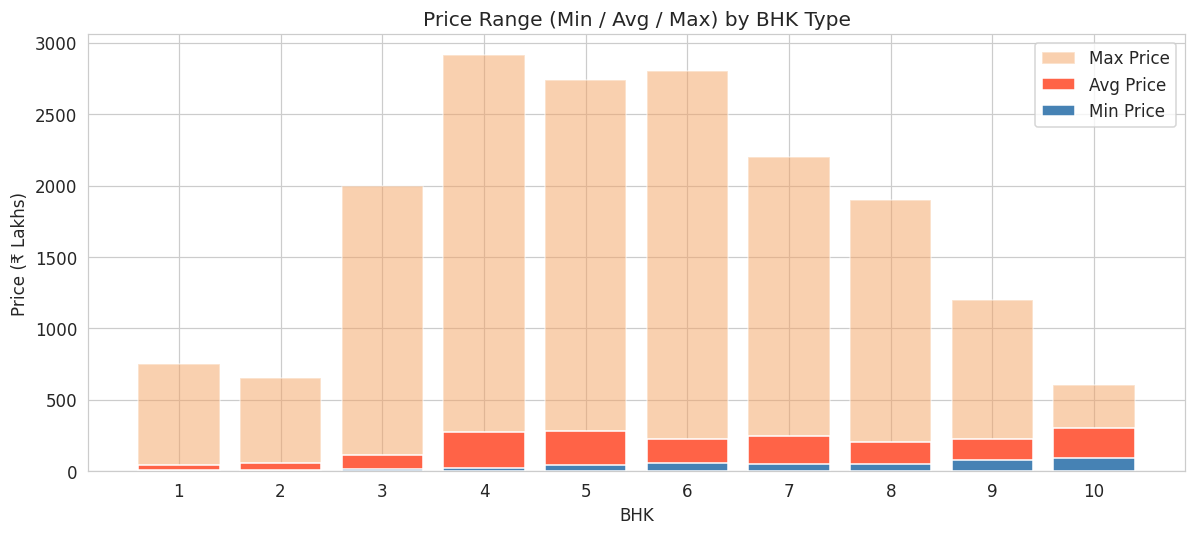

,bhk,avg_price_lakhs,min_price_lakhs,max_price_lakhs,total_listings
0,1,44.24,8.0,750,638
1,2,59.54,10.5,650,5517
2,3,110.96,12.0,2000,4817
3,4,271.60,24.5,2912,1388
4,5,280.57,44.5,2736,348
5,6,224.60,58.0,2800,220
6,7,245.68,52.0,2200,99
7,8,207.67,50.0,1900,85
8,9,226.85,75.0,1200,48
9,10,303.00,90.0,600,10


In [5]:
q4 = pd.DataFrame({
    'bhk': [1,2,3,4,5,6,7,8,9,10],
    'avg_price_lakhs': [44.24,59.54,110.96,271.6,280.57,224.6,245.68,207.67,226.85,303],
    'min_price_lakhs': [8,10.5,12,24.5,44.5,58,52,50,75,90],
    'max_price_lakhs': [750,650,2000,2912,2736,2800,2200,1900,1200,600],
    'total_listings': [638,5517,4817,1388,348,220,99,85,48,10]
})

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(q4['bhk'], q4['max_price_lakhs'], color='#f4a261', alpha=0.5, label='Max Price')
ax.bar(q4['bhk'], q4['avg_price_lakhs'], color='tomato', label='Avg Price')
ax.bar(q4['bhk'], q4['min_price_lakhs'], color='steelblue', label='Min Price')
ax.set_xlabel('BHK')
ax.set_ylabel('Price (₹ Lakhs)')
ax.set_title('Price Range (Min / Avg / Max) by BHK Type')
ax.set_xticks(q4['bhk'])
ax.legend()
plt.tight_layout()
plt.savefig('outputs/q4_price_range.png', dpi=150, bbox_inches='tight')
plt.show()
q4


**Key insight:** The max prices are extraordinary — a 3 BHK listed at ₹2,000 lakhs (₹20 crore), a 4 BHK at ₹2,912 lakhs. These are either luxury penthouses or data anomalies, and illustrate why median would be more robust than mean for this dataset.

## Query 5 — Most Expensive Localities by Average Total Price

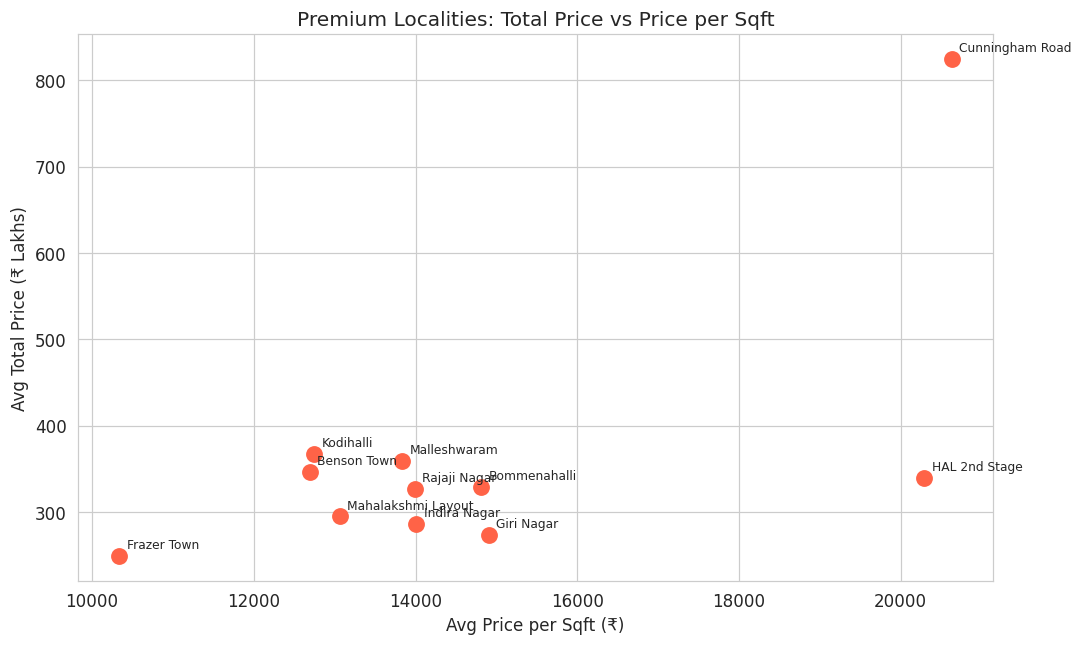

,location,avg_price_lakhs,avg_price_per_sqft
0,Cunningham Road,824.38,20632.48
1,Kodihalli,367.73,12745.70
2,Malleshwaram,359.41,13838.68
3,Benson Town,346.74,12688.82
4,HAL 2nd Stage,339.27,20291.83
5,Bommenahalli,328.73,14806.42
6,Rajaji Nagar,326.78,13989.07
7,Mahalakshmi Layout,294.85,13063.47
8,Indira Nagar,286.32,14009.30
9,Giri Nagar,273.14,14904.45


In [6]:
q5 = pd.DataFrame({
    'location': ['Cunningham Road','Kodihalli','Malleshwaram','Benson Town',
                 'HAL 2nd Stage','Bommenahalli','Rajaji Nagar',
                 'Mahalakshmi Layout','Indira Nagar','Giri Nagar','Frazer Town'],
    'avg_price_lakhs': [824.38,367.73,359.41,346.74,339.27,328.73,326.78,294.85,286.32,273.14,248.64],
    'avg_price_per_sqft': [20632.48,12745.7,13838.68,12688.82,20291.83,14806.42,13989.07,13063.47,14009.3,14904.45,10335.89]
})

fig, ax = plt.subplots(figsize=(10,6))
scatter = ax.scatter(q5['avg_price_per_sqft'], q5['avg_price_lakhs'],
                     s=100, color='tomato', zorder=3)
for _, row in q5.iterrows():
    ax.annotate(row['location'], (row['avg_price_per_sqft'], row['avg_price_lakhs']),
                fontsize=8, xytext=(5,5), textcoords='offset points')
ax.set_xlabel('Avg Price per Sqft (₹)')
ax.set_ylabel('Avg Total Price (₹ Lakhs)')
ax.set_title('Premium Localities: Total Price vs Price per Sqft')
plt.tight_layout()
plt.savefig('outputs/q5_expensive_localities.png', dpi=150, bbox_inches='tight')
plt.show()
q5


**Key insight:** Cunningham Road dominates on both metrics — highest per sqft AND highest total price (₹824L avg). Frazer Town is interesting: relatively lower per sqft (₹10,336) but still in the top 11 by total price, suggesting larger property sizes there.

## Query 6 — Price per Sqft Outlier Detection
Properties priced significantly above their locality average — potential luxury listings or data anomalies.

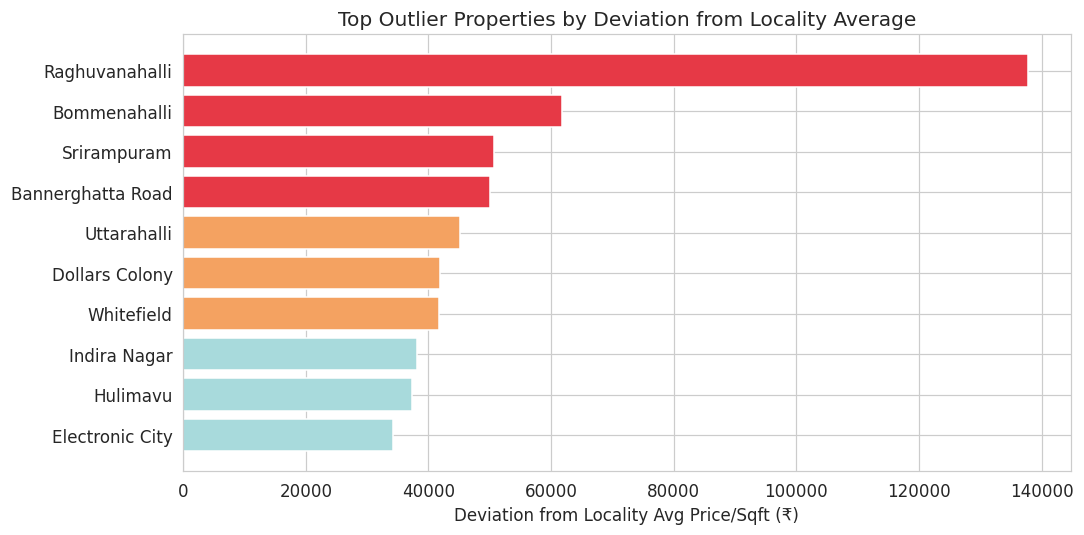

,location,bhk,price,price_per_sqft,avg_locality_ppsf,deviation
0,Raghuvanahalli,1,750,176471.0,38647.93,137822.67
1,Bommenahalli,4,2250,76530.6,14806.42,61724.19
2,Srirampuram,1,500,76923.1,26255.18,50667.90
3,Bannerghatta Road,5,1400,56000.0,5917.36,50082.64
4,Uttarahalli,5,200,50000.0,4891.56,45108.44
5,Dollars Colony,4,2600,59770.1,17830.58,41939.53
6,Whitefield,3,718,47994.6,6202.28,41792.37
7,Indira Nagar,4,1250,52083.3,14009.30,38074.02
8,Hulimavu,1,220,44000.0,6740.60,37259.40
9,Electronic City,4,700,38888.9,4593.21,34295.68


In [7]:
q6 = pd.DataFrame({
    'location': ['Raghuvanahalli','Bommenahalli','Srirampuram','Bannerghatta Road',
                 'Uttarahalli','Dollars Colony','Whitefield','Indira Nagar',
                 'Hulimavu','Electronic City'],
    'bhk': [1,4,1,5,5,4,3,4,1,4],
    'total_sqft': [425,2940,650,2500,400,4350,1496,2400,500,1800],
    'price': [750,2250,500,1400,200,2600,718,1250,220,700],
    'price_per_sqft': [176471,76530.6,76923.1,56000,50000,59770.1,47994.6,52083.3,44000,38888.9],
    'avg_locality_ppsf': [38647.93,14806.42,26255.18,5917.36,4891.56,17830.58,6202.28,14009.3,6740.6,4593.21],
    'deviation': [137822.67,61724.19,50667.9,50082.64,45108.44,41939.53,41792.37,38074.02,37259.4,34295.68]
})

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#e63946' if d > 50000 else '#f4a261' if d > 40000 else '#a8dadc' for d in q6['deviation']]
ax.barh(q6['location'], q6['deviation'], color=colors)
ax.set_xlabel('Deviation from Locality Avg Price/Sqft (₹)')
ax.set_title('Top Outlier Properties by Deviation from Locality Average')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/q6_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
q6[['location','bhk','price','price_per_sqft','avg_locality_ppsf','deviation']]


**Key insight:** Raghuvanahalli has a 1 BHK listed at ₹1,76,471/sqft — nearly 4.5x the locality average. This is almost certainly a data entry error (sqft recorded too low) rather than a genuine luxury listing. This kind of outlier detection is exactly why a cleaned, queryable database is more useful than a raw CSV.

## Query 7 — Bathroom Count vs Price Relationship

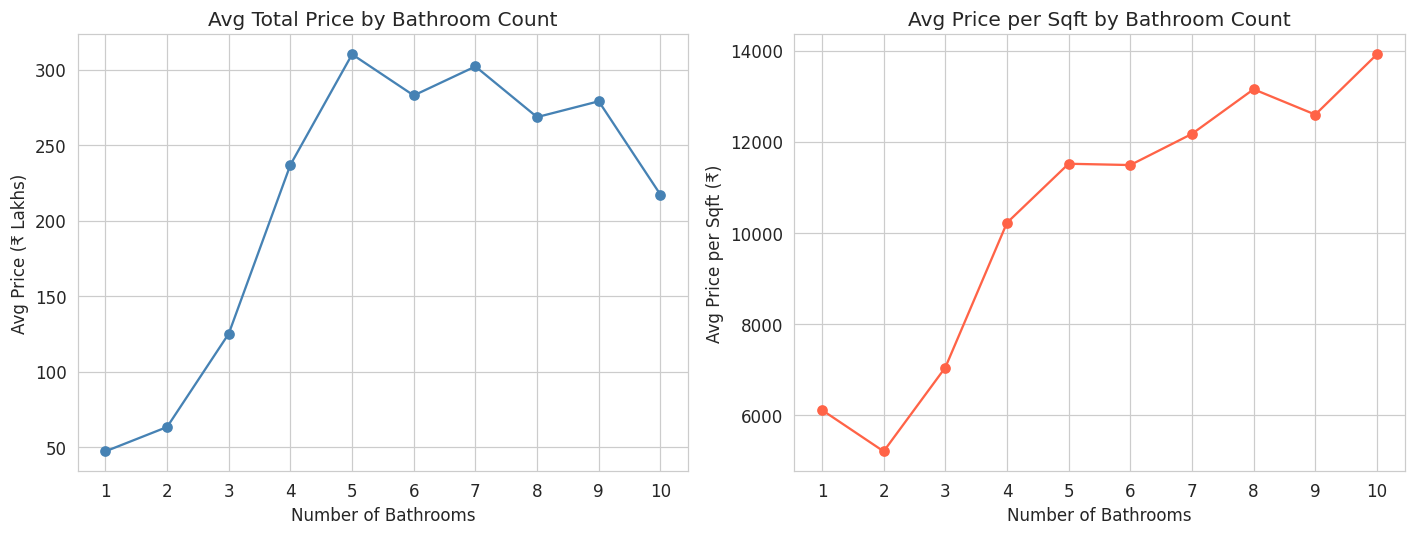

,bath,total_listings,avg_price_lakhs,avg_price_per_sqft
0,1,779,47.22,6115.05
1,2,6892,63.35,5208.14
2,3,3273,125.16,7047.01
3,4,1220,237.04,10222.31
4,5,521,310.23,11517.39
5,6,267,282.98,11489.13
6,7,101,302.19,12173.02
7,8,64,268.64,13152.37
8,9,40,279.12,12595.88
9,10,13,217.31,13918.36


In [8]:
q7 = pd.DataFrame({
    'bath': [1,2,3,4,5,6,7,8,9,10],
    'total_listings': [779,6892,3273,1220,521,267,101,64,40,13],
    'avg_price_lakhs': [47.22,63.35,125.16,237.04,310.23,282.98,302.19,268.64,279.12,217.31],
    'avg_price_per_sqft': [6115.05,5208.14,7047.01,10222.31,11517.39,11489.13,12173.02,13152.37,12595.88,13918.36]
})

fig, axes = plt.subplots(1,2,figsize=(13,5))

axes[0].plot(q7['bath'], q7['avg_price_lakhs'], marker='o', color='steelblue')
axes[0].set_xlabel('Number of Bathrooms')
axes[0].set_ylabel('Avg Price (₹ Lakhs)')
axes[0].set_title('Avg Total Price by Bathroom Count')
axes[0].set_xticks(q7['bath'])

axes[1].plot(q7['bath'], q7['avg_price_per_sqft'], marker='o', color='tomato')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Avg Price per Sqft (₹)')
axes[1].set_title('Avg Price per Sqft by Bathroom Count')
axes[1].set_xticks(q7['bath'])

plt.tight_layout()
plt.savefig('outputs/q7_bathrooms.png', dpi=150, bbox_inches='tight')
plt.show()
q7


**Key insight:** Price rises strongly from 1 to 5 bathrooms, then plateaus and even dips slightly for 6-10 bath properties. This suggests diminishing returns beyond 5 bathrooms — ultra-high bathroom counts don't translate linearly into higher prices, possibly because such properties are rare and irregularly priced.

## Summary of Key Findings

| Finding | Detail |
|---|---|
| Most expensive locality (per sqft) | Cunningham Road — ₹20,632/sqft |
| Highest supply locality | Whitefield — 532 listings |
| Most common property type | 2 BHK (5,517 listings, 42% of market) |
| Biggest price jump | 3 BHK (₹111L avg) → 4 BHK (₹272L avg) |
| Biggest outlier | Raghuvanahalli 1BHK at ₹1,76,471/sqft (4.5x locality avg) |
| IT corridor pattern | High supply suburbs (Whitefield, Electronic City) are NOT in top price localities |
